# District-level Δr — does the crop mask help *within* each district?

`gsv_preds_exploration.ipynb` computes **one pooled correlation per state**: all districts
and all years thrown into a single Pearson r. This notebook computes a **separate
correlation for each district** across its 12 years, then measures how masking changes it.

The two answer different questions:

| Statistic | Question it answers |
|---|---|
| **Pooled** (state) | Does masked GCVI rank *districts* by yield better? |
| **Per-district** (here) | Does masked GCVI track a district's *year-to-year* yield changes better? |

For forecasting, the second is usually the more relevant one — but the two can disagree,
and in this data they do. That divergence is documented in the final section.

Output: `../../outputs/district_level_delta.csv`

In [1]:
import nbformat, numpy as np, pandas as pd, os, glob, re
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 15,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 13, 'legend.title_fontsize': 13, 'figure.titlesize': 20,
})

os.makedirs('../../outputs', exist_ok=True)

# Reuse the config + helpers from the state-level notebook so the GCVI extraction,
# NAME_FIXES and mask conventions are guaranteed identical.
SRC = '../02_mask_analysis/gsv_preds_exploration.ipynb'
_nb  = nbformat.read(SRC, as_version=4)
_cfg = next(c.source for c in _nb.cells if c.get('id') == 'ee4f17d1')
ns = {}
exec(_cfg, ns)
REGIONS, REGION_MASKS = ns['REGIONS'], ns['REGION_MASKS']
load_yield, extract_gcvi = ns['load_yield'], ns['extract_gcvi']
REGION_LABELS = ns['REGION_LABELS']
print(f"reusing config from {SRC}: {len(REGIONS)} states")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Configured 30 states.
reusing config from ../02_mask_analysis/gsv_preds_exploration.ipynb: 30 states


## 1. Per-district correlations

For each state we extract district-mean GCVI twice — once unmasked (`raw`) and once with
the crop mask — join both to district yield, and compute a Pearson r **per district**
across years.

Guards applied to each district:
- at least **5 usable years** (a 12-point series is already thin; below 5 is meaningless)
- non-zero variance in both GCVI and yield, else `pearsonr` returns NaN silently

⚠ Each district correlation rests on ~12 observations, so individual values are noisy.
Only aggregate patterns should be read from them.

In [2]:
MIN_YEARS = 5
rows, skipped = [], []

for rk, cfg in REGIONS.items():
    try:
        yl = load_yield(cfg['state_name'])
        crop_mask = REGION_MASKS[rk][2]          # 'crop' for Punjab/MP, else 'jordi'

        panels = {}
        for m in ['raw', crop_mask]:
            g = extract_gcvi(rk, m).merge(yl, on=['district', 'year'], how='inner').dropna()
            # NOTE: we do NOT overwrite yield where the mask is empty. gcvi_mean = 0 means
            # "no rice pixels retained here", which is a real rice-presence signal and is
            # kept as such (same treatment as logo_cv_all_states.ipynb). Zeroing yield on
            # those rows put them all at (0, 0) and inflated r mechanically -- it took
            # Nagaland's masked r from 0.112 to 0.950. No rows are dropped.
            panels[m] = g

        raw_df, msk_df = panels['raw'], panels[crop_mask]
        for d in sorted(set(raw_df['district']) & set(msk_df['district'])):
            a = raw_df[raw_df['district'] == d]
            b = msk_df[msk_df['district'] == d]
            if len(a) < MIN_YEARS or len(b) < MIN_YEARS:
                skipped.append((rk, d, 'too few years')); continue
            if (a['gcvi_mean'].nunique() < 2 or a['yield_kg_ha'].nunique() < 2 or
                b['gcvi_mean'].nunique() < 2 or b['yield_kg_ha'].nunique() < 2):
                skipped.append((rk, d, 'zero variance')); continue

            r_raw = stats.pearsonr(a['gcvi_mean'], a['yield_kg_ha'])[0]
            r_msk = stats.pearsonr(b['gcvi_mean'], b['yield_kg_ha'])[0]
            if not (np.isfinite(r_raw) and np.isfinite(r_msk)):
                skipped.append((rk, d, 'non-finite r')); continue

            rows.append({'region_key': rk, 'State': cfg['state_name'],
                         'region_label': REGION_LABELS[rk], 'district': d,
                         'n_years': len(a), 'r_raw': r_raw, 'r_mask': r_msk,
                         'delta': r_msk - r_raw,
                         'rel': (r_msk - r_raw) / (1 - r_raw)})
        print(f"  {rk:<20} ok", flush=True)
    except Exception as e:
        print(f"  {rk:<20} FAILED  {type(e).__name__}: {e}", flush=True)

dd = pd.DataFrame(rows)
dd.to_csv('../../outputs/district_level_delta.csv', index=False)
print(f"\n{len(dd)} districts across {dd['region_key'].nunique()} states"
      f"   ({len(skipped)} skipped)")
if skipped:
    from collections import Counter
    for reason, n in Counter(r for _, _, r in skipped).items():
        print(f"   skipped — {reason}: {n}")

  punjab               ok


  mp                   ok


  up                   ok


  wb                   ok


  telangana            ok


...

  andaman_nicobar      ok


<string>:312: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


  dadra_nagar_haveli   ok



514 districts across 27 states   (110 skipped)
   skipped — zero variance: 83
   skipped — too few years: 27


<string>:312: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


## 2. How much does the mask help at district level?

districts            : 514
median years/district: 12
mean   Δr            : +0.0079
median Δr            : +0.0079
improved (Δr > 0)    : 57%
one-sample t-test vs 0: t=0.95, p=0.3441


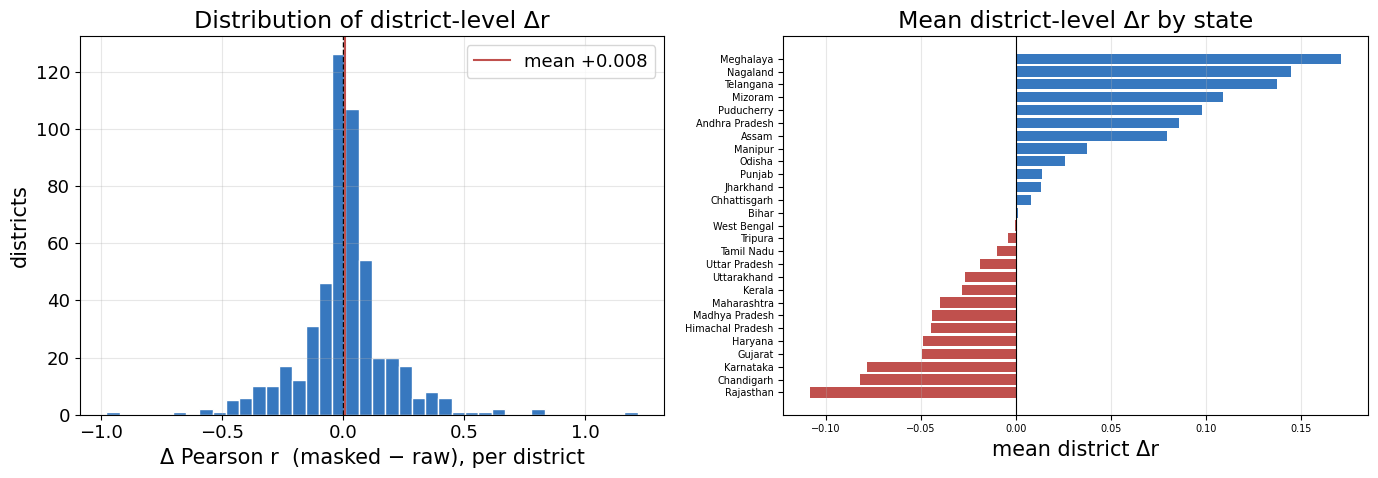

In [3]:
print(f"districts            : {len(dd)}")
print(f"median years/district: {dd['n_years'].median():.0f}")
print(f"mean   Δr            : {dd['delta'].mean():+.4f}")
print(f"median Δr            : {dd['delta'].median():+.4f}")
print(f"improved (Δr > 0)    : {100 * (dd['delta'] > 0).mean():.0f}%")
t, p = stats.ttest_1samp(dd['delta'].dropna(), 0)
print(f"one-sample t-test vs 0: t={t:.2f}, p={p:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dd['delta'].dropna(), bins=40, color='#3778bf', edgecolor='white')
axes[0].axvline(0, color='black', ls='--', lw=1)
axes[0].axvline(dd['delta'].mean(), color='#c0504d', lw=1.5,
                label=f"mean {dd['delta'].mean():+.3f}")
axes[0].set_xlabel('Δ Pearson r  (masked − raw), per district')
axes[0].set_ylabel('districts'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Distribution of district-level Δr')

o = dd.groupby('region_label')['delta'].mean().sort_values()
axes[1].barh(o.index, o.values, color=np.where(o.values > 0, '#3778bf', '#c0504d'))
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('mean district Δr'); axes[1].tick_params(labelsize=7)
axes[1].set_title('Mean district-level Δr by state'); axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../../outputs/district_delta_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Pooled vs per-district — they disagree

The state-level notebook reports a large mean improvement (Δr ≈ +0.44 pooled). Averaging
the per-district Δr gives something far smaller. Both are correct; they measure different
things.

pooled Δr   : mean +0.192
district Δr : mean +0.013

r(pooled Δr, mean district Δr) = +0.17  p=0.3860  n=27


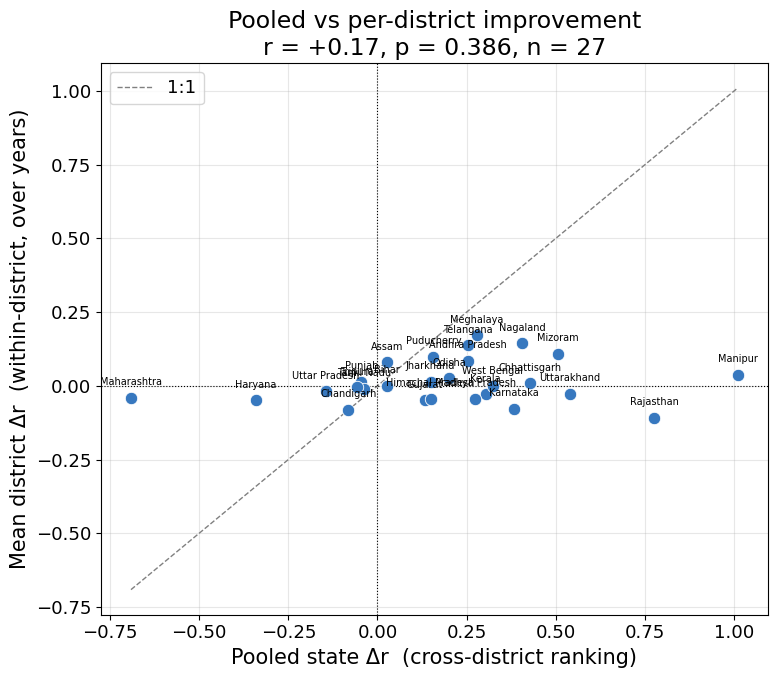

In [4]:
pooled = pd.read_csv('../../outputs/gcvi_yield_correlation.csv')
pr = []
for k in pooled['region'].unique():
    s = pooled[pooled['region'] == k]
    raw  = s[s['mask'] == 'raw']['r'].values
    crop = s[s['mask'].isin(['crop', 'jordi'])]['r'].values
    b = next(iter(raw), np.nan)
    pr.append({'region_key': k, 'pooled_baseline': b,
               'pooled_delta': next(iter(crop - raw), np.nan)})
P = pd.DataFrame(pr)

D = (dd.groupby(['region_key', 'region_label'])
       .agg(district_delta=('delta', 'mean'), n_dist=('delta', 'size'))
       .reset_index().merge(P, on='region_key', how='inner').dropna())

r, p = stats.pearsonr(D['pooled_delta'], D['district_delta'])
print(f"pooled Δr   : mean {D['pooled_delta'].mean():+.3f}")
print(f"district Δr : mean {D['district_delta'].mean():+.3f}")
print(f"\nr(pooled Δr, mean district Δr) = {r:+.2f}  p={p:.4f}  n={len(D)}")

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(D['pooled_delta'], D['district_delta'], s=80, color='#3778bf',
           edgecolors='white', linewidths=0.6, zorder=3)
for _, row in D.iterrows():
    ax.annotate(row['region_label'], (row['pooled_delta'], row['district_delta']),
                fontsize=7, textcoords='offset points', xytext=(0, 9), ha='center')
lo = min(D['pooled_delta'].min(), D['district_delta'].min())
hi = max(D['pooled_delta'].max(), D['district_delta'].max())
ax.plot([lo, hi], [lo, hi], ls='--', c='grey', lw=1, label='1:1')
ax.axhline(0, color='black', lw=0.8, ls=':'); ax.axvline(0, color='black', lw=0.8, ls=':')
ax.set_xlabel('Pooled state Δr  (cross-district ranking)')
ax.set_ylabel('Mean district Δr  (within-district, over years)')
ax.set_title(f'Pooled vs per-district improvement\nr = {r:+.2f}, p = {p:.3f}, n = {len(D)}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../outputs/pooled_vs_district_delta.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings

**1. At district level the crop mask barely helps.** Mean Δr is near zero and only about
half of districts improve — against a pooled state-level mean of roughly +0.44. The mask's
apparent benefit comes almost entirely from **ranking districts against each other**, not
from tracking any single district's year-to-year variation.

**2. Each district correlation rests on ~12 points.** Individual district values are very
noisy; only the aggregate distribution is meaningful.

**3. The two statistics can disagree in sign for the same predictor.** Census rice share
correlates **negatively** with pooled state Δr but **positively** with mean district Δr.
That is a Simpson's-paradox-shaped result, not an error — decide which question you are
answering before quoting either number.

**Practical implication:** if the goal is a *forecasting* model that predicts a district's
yield in an unseen year, the district-level result is the relevant one, and it says the
crop mask contributes little. If the goal is a cross-sectional map of relative yield, the
pooled result applies.

## Pooled vs district, as scatter

The same comparison as the summary table, drawn. Each panel plots **masked r against
raw r** with a 1:1 line: a point above the line is a unit where the mask improved the
correlation, below is where it hurt.

- **left** — one point per state (n = 27), each a Pearson over all that state's
  district-years. Points sit well above the line.
- **right** — one point per district (n = 514), each a Pearson over that district's
  ~12 years. The cloud straddles the line.

Same data, same masks, two units of observation, opposite conclusions.

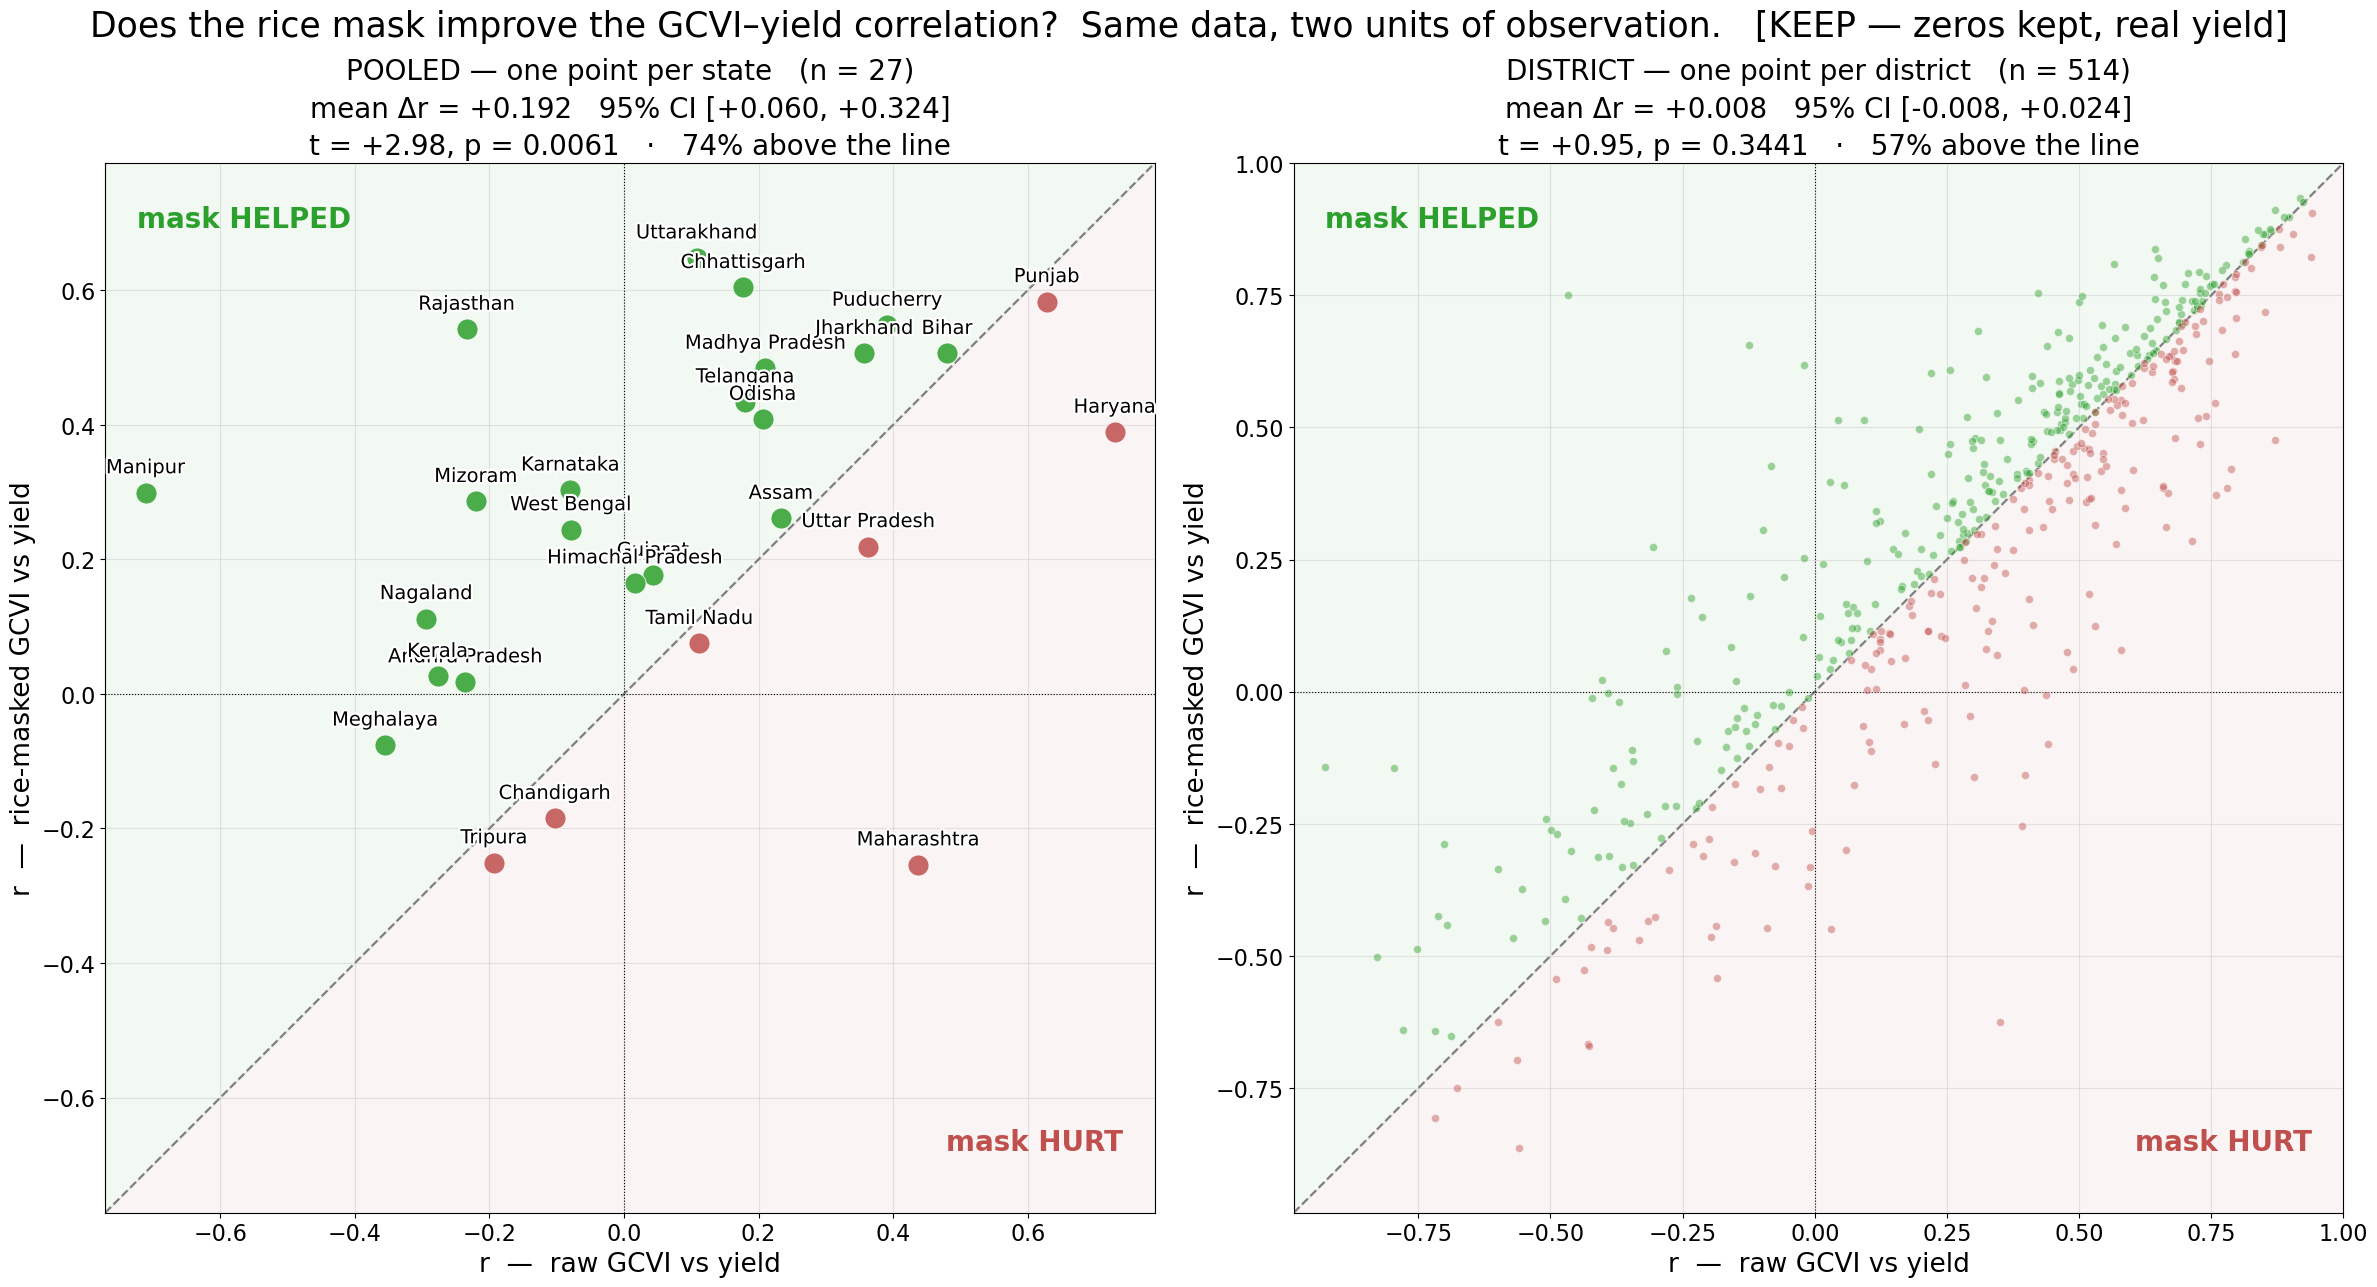

In [5]:
import matplotlib.patheffects as pe

# ── pooled r per state, from the correlation CSV (KEEP handling) ──────────
C = pd.read_csv('../../outputs/gcvi_yield_correlation.csv')
rows = []
for k in C.region.unique():
    s = C[C.region == k]
    raw, msk = s[s['mask'] == 'raw'], s[s['mask'].isin(['crop', 'jordi'])]
    if raw.empty or msk.empty:
        continue
    rows.append({'region_key': k, 'r_raw': raw.iloc[0]['r'], 'r_mask': msk.iloc[0]['r'],
                 'n': int(raw.iloc[0]['n'])})
P = pd.DataFrame(rows)
P['delta'] = P.r_mask - P.r_raw
P['label'] = P.region_key.map(REGION_LABELS).fillna(P.region_key)


def scatter_pair(P, D, tag, outfile):
    """masked r vs raw r, states on the left and districts on the right.

    Titles carry n, mean Δr, its 95% CI, t and p, so each panel is self-contained.
    This figure holds a lot of text, so it sets sizes above the notebook rcParams.
    """
    fig, axes = plt.subplots(1, 2, figsize=(24, 13))

    for ax, (df, ttl, unit) in zip(axes, [
            (P, 'POOLED — one point per state',      'state'),
            (D, 'DISTRICT — one point per district', 'district')]):
        d = df[['r_raw', 'r_mask']].dropna()
        lo = min(d.r_raw.min(), d.r_mask.min()) - 0.06
        hi = max(d.r_raw.max(), d.r_mask.max()) + 0.06
        big = unit == 'state'

        ax.fill_between([lo, hi], [lo, hi], hi, color='#2ca02c', alpha=0.06, zorder=0)
        ax.fill_between([lo, hi], lo, [lo, hi], color='#c0504d', alpha=0.06, zorder=0)
        ax.plot([lo, hi], [lo, hi], ls='--', c='grey', lw=1.6, zorder=2)

        up = df.r_mask > df.r_raw
        for sel, colr in [(up, '#2ca02c'), (~up, '#c0504d')]:
            ax.scatter(df.loc[sel, 'r_raw'], df.loc[sel, 'r_mask'],
                       s=230 if big else 34, color=colr,
                       alpha=0.85 if big else 0.45,
                       edgecolors='white', linewidths=0.7, zorder=3)

        ax.axhline(0, color='black', lw=0.8, ls=':')
        ax.axvline(0, color='black', lw=0.8, ls=':')
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
        ax.set_xlabel('r  —  raw GCVI vs yield', fontsize=19)
        ax.set_ylabel('r  —  rice-masked GCVI vs yield', fontsize=19)
        ax.tick_params(labelsize=16)
        ax.grid(alpha=0.3)

        v = df['delta'].dropna()
        t, pv = stats.ttest_1samp(v, 0)
        ci = stats.t.interval(0.95, len(v) - 1,
                              loc=v.mean(), scale=v.std(ddof=1) / np.sqrt(len(v)))
        ax.set_title(f"{ttl}   (n = {len(v)})\n"
                     f"mean Δr = {v.mean():+.3f}   95% CI [{ci[0]:+.3f}, {ci[1]:+.3f}]\n"
                     f"t = {t:+.2f}, p = {pv:.4f}   ·   {100*(v>0).mean():.0f}% above the line",
                     fontsize=20, linespacing=1.45)
        ax.text(0.03, 0.96, 'mask HELPED', transform=ax.transAxes, va='top',
                fontsize=20, color='#2ca02c', fontweight='bold')
        ax.text(0.97, 0.06, 'mask HURT', transform=ax.transAxes, ha='right',
                fontsize=20, color='#c0504d', fontweight='bold')

    for _, r in P.iterrows():                       # name the states
        axes[0].annotate(r['label'], (r.r_raw, r.r_mask), fontsize=14,
                         textcoords='offset points', xytext=(0, 14), ha='center',
                         path_effects=[pe.withStroke(linewidth=3.2, foreground='white')])

    fig.suptitle('Does the rice mask improve the GCVI–yield correlation?  '
                 f'Same data, two units of observation.   [{tag}]', y=0.99, fontsize=25)
    plt.tight_layout()
    plt.savefig(outfile, dpi=150, bbox_inches='tight')
    plt.show()


scatter_pair(P, dd, 'KEEP — zeros kept, real yield',
             '../../outputs/pooled_vs_district_scatter.png')

## Inside single districts

The district Δr above is a summary of ~12 points. This draws those points, so the
correlation is visible rather than asserted. Rows are districts, columns are the two
GCVI series; each point is one year, labelled.

Set `STATE` / `DISTRICTS` to look at any others.

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


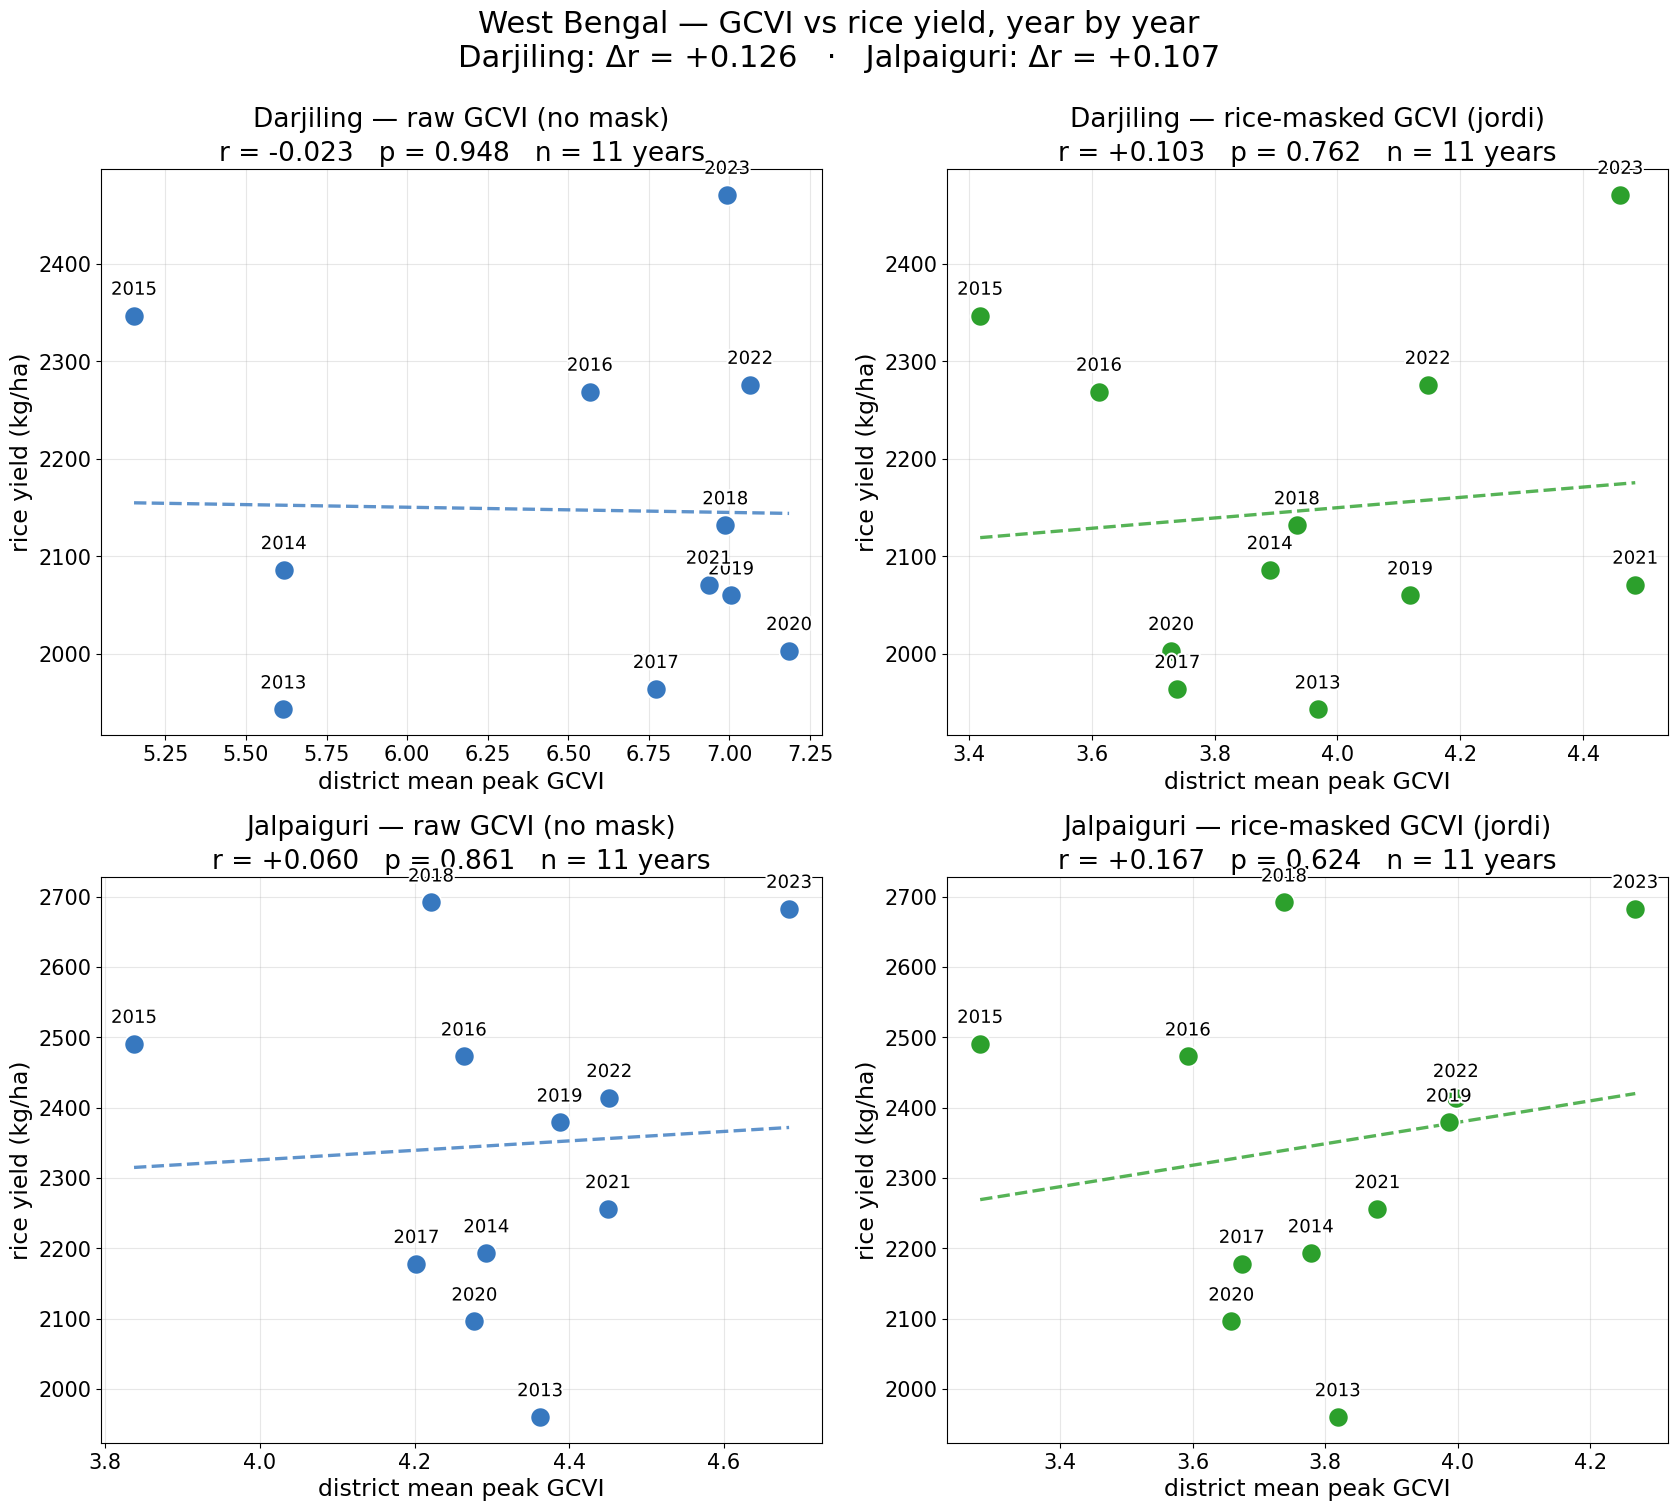


Darjiling
      jordi    raw  yield_kg_ha
year                           
2013  3.968  5.616       1943.0
2014  3.890  5.617       2086.0
2015  3.419  5.152       2347.0
2016  3.612  6.567       2269.0
2017  3.739  6.772       1964.0
2018  3.934  6.987       2132.0
2019  4.118  7.005       2060.0
2020  3.729  7.185       2003.0
2021  4.485  6.936       2071.0
2022  4.147  7.064       2276.0
2023  4.460  6.993       2471.0

Jalpaiguri
      jordi    raw  yield_kg_ha
year                           
2013  3.819  4.362       1960.0
2014  3.778  4.293       2193.0
2015  3.279  3.838       2491.0
2016  3.592  4.264       2473.0
2017  3.674  4.203       2178.0
2018  3.738  4.221       2692.0
2019  3.986  4.388       2379.0
2020  3.658  4.277       2096.0
2021  3.879  4.450       2256.0
2022  3.997  4.452       2414.0
2023  4.268  4.684       2683.0


In [6]:
STATE     = 'wb'
DISTRICTS = ['Darjiling', 'Jalpaiguri']

_mask = REGION_MASKS[STATE][2]
_y    = load_yield(REGIONS[STATE]['state_name'])[['district', 'year', 'yield_kg_ha']]
_g    = pd.read_csv('../../data/processed/gcvi_district_cache.csv')
_g    = _g[_g.region_key == STATE]

SERIES = [('raw', 'raw GCVI (no mask)', '#3778bf'),
          (_mask, f'rice-masked GCVI ({_mask})', '#2ca02c')]

fig, axes = plt.subplots(len(DISTRICTS), 2, figsize=(17, 7.6 * len(DISTRICTS)),
                         squeeze=False)

for i, dist in enumerate(DISTRICTS):
    for j, (mk, lab, col) in enumerate(SERIES):
        ax = axes[i, j]
        s = (_g[(_g.district == dist) & (_g['mask'] == mk)][['year', 'gcvi_mean']]
             .merge(_y[_y.district == dist], on='year').dropna()
             .sort_values('year'))
        if len(s) < 3:
            ax.text(0.5, 0.5, 'too few years', ha='center', va='center',
                    transform=ax.transAxes, color='grey', fontsize=18)
            continue

        ax.scatter(s.gcvi_mean, s.yield_kg_ha, s=210, color=col,
                   edgecolors='white', linewidths=1.2, zorder=3)
        for _, r in s.iterrows():                      # label each point with its year
            ax.annotate(str(int(r.year)), (r.gcvi_mean, r.yield_kg_ha),
                        fontsize=13, textcoords='offset points', xytext=(0, 15),
                        ha='center', zorder=4,
                        path_effects=[pe.withStroke(linewidth=3, foreground='white')])

        rr, pv = stats.pearsonr(s.gcvi_mean, s.yield_kg_ha)
        lr = stats.linregress(s.gcvi_mean, s.yield_kg_ha)
        xs = np.linspace(s.gcvi_mean.min(), s.gcvi_mean.max(), 50)
        ax.plot(xs, lr.intercept + lr.slope * xs, color=col, lw=2.4, ls='--',
                alpha=0.8, zorder=2)

        ax.set_xlabel('district mean peak GCVI', fontsize=17)
        ax.set_ylabel('rice yield (kg/ha)', fontsize=17)
        ax.tick_params(labelsize=15)
        ax.set_title(f'{dist} — {lab}\nr = {rr:+.3f}   p = {pv:.3f}   n = {len(s)} years',
                     fontsize=19, linespacing=1.4)
        ax.grid(alpha=0.3)

_d = dd[(dd.region_key == STATE) & (dd.district.isin(DISTRICTS))]
_txt = '   ·   '.join(f"{r.district}: Δr = {r.delta:+.3f}" for _, r in _d.iterrows())
fig.suptitle(f'{REGION_LABELS.get(STATE, STATE)} — GCVI vs rice yield, year by year\n{_txt}',
             y=0.995, fontsize=22)
plt.tight_layout()
plt.savefig(f'../../outputs/district_scatter_{STATE}.png', dpi=150, bbox_inches='tight')
plt.show()

for dist in DISTRICTS:
    s = (_g[(_g.district == dist) & (_g['mask'].isin(['raw', _mask]))]
         .pivot_table(index='year', columns='mask', values='gcvi_mean')
         .merge(_y[_y.district == dist].set_index('year')[['yield_kg_ha']],
                left_index=True, right_index=True))
    print(f"\n{dist}")
    print(s.round(3).to_string())

### The same figure under the ZERO handling

Rows kept, but **yield overwritten with 0 wherever `gcvi_mean == 0`** — the original
notebook behaviour from §15 of `RESULTS_SUMMARY.txt`. Recomputed from scratch here,
both panels, so the two figures are directly comparable.

Expect the pooled panel to stretch upward (those states gain a cluster of fabricated
(0, 0) points) while the district panel barely moves — none of the 514 districts that
survive the ≥5-year and zero-variance filters contains an empty-mask year, so the
overwrite never fires there.

ZERO  pooled  : n=  27  mean Δr=+0.4383
KEEP  pooled  : n=  27  mean Δr=+0.1919
ZERO  district: n= 514  mean Δr=+0.0079
KEEP  district: n= 514  mean Δr=+0.0079


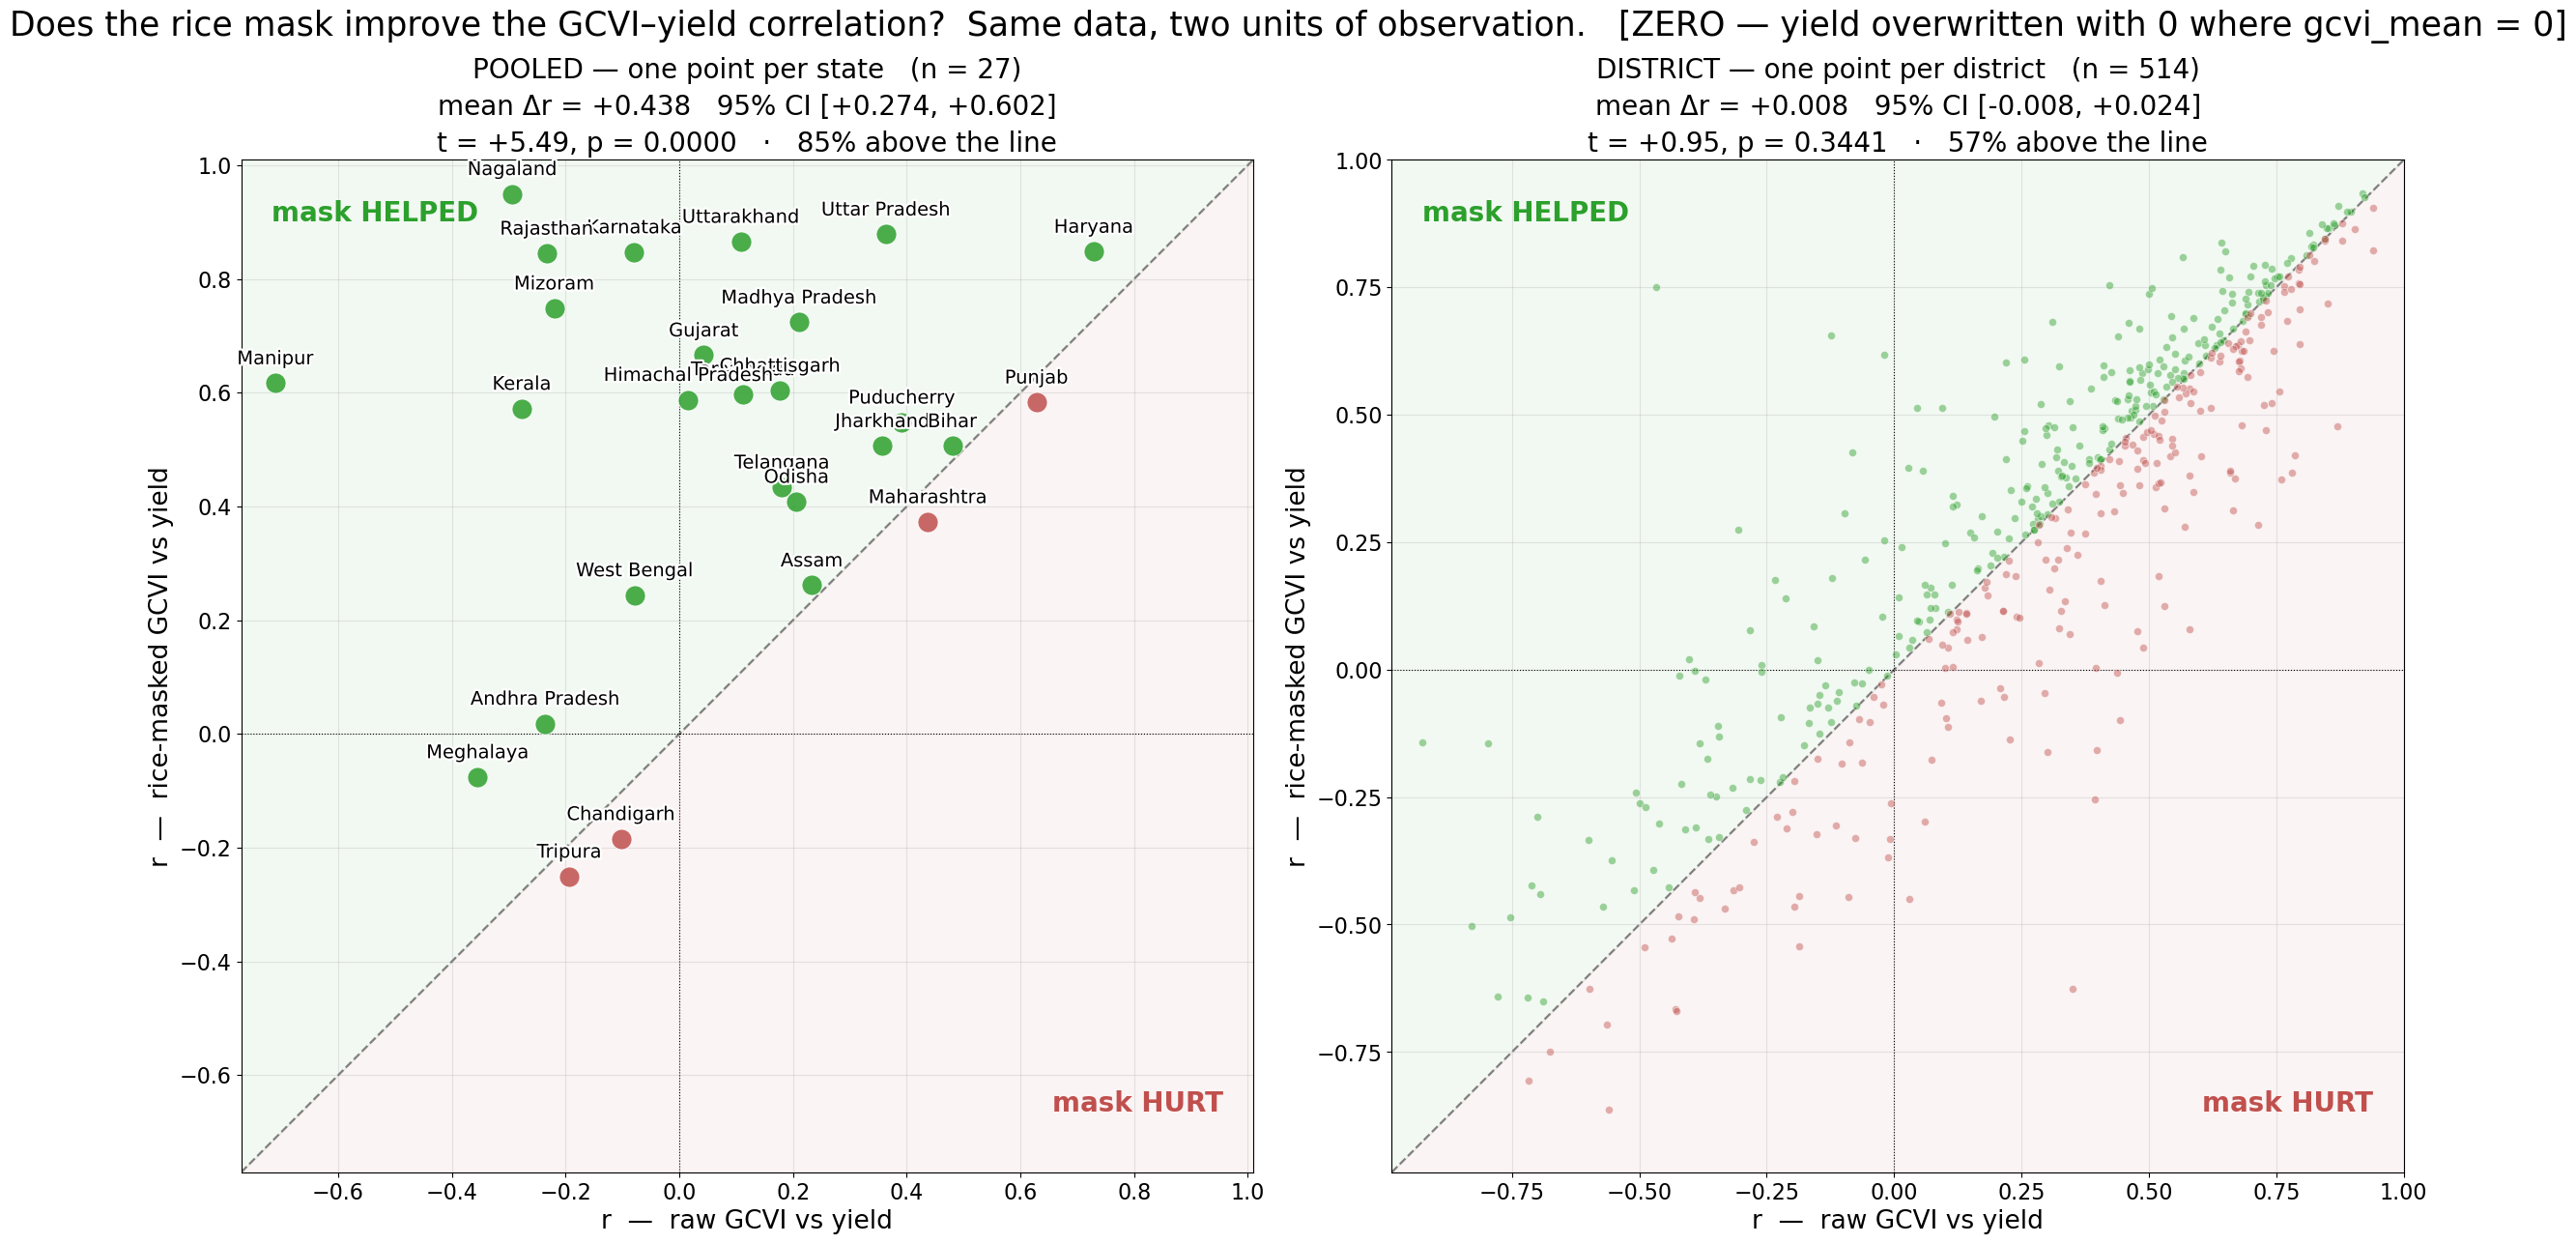

In [7]:
# ── pooled, ZERO ─────────────────────────────────────────────────────────
_G = pd.read_csv('../../data/processed/gcvi_district_cache.csv')

def pooled_r(k, mask, zero_yield):
    y = load_yield(REGIONS[k]['state_name'])[['district', 'year', 'yield_kg_ha']]
    g = _G[(_G.region_key == k) & (_G['mask'] == mask)][['district', 'year', 'gcvi_mean']]
    if g.empty:
        return np.nan
    m = g.merge(y, on=['district', 'year']).dropna()
    if zero_yield:
        m.loc[m.gcvi_mean == 0, 'yield_kg_ha'] = 0
    if len(m) < 4 or m.gcvi_mean.nunique() < 2 or m.yield_kg_ha.nunique() < 2:
        return np.nan
    return stats.pearsonr(m.gcvi_mean, m.yield_kg_ha).statistic

rows = []
for k in REGIONS:
    mk = REGION_MASKS[k][2]
    a, b = pooled_r(k, 'raw', True), pooled_r(k, mk, True)
    if np.isfinite(a) and np.isfinite(b):
        rows.append({'region_key': k, 'r_raw': a, 'r_mask': b, 'delta': b - a})
PZ = pd.DataFrame(rows)
PZ['label'] = PZ.region_key.map(REGION_LABELS).fillna(PZ.region_key)

# ── district, ZERO ───────────────────────────────────────────────────────
rows = []
for k in REGIONS:
    mk = REGION_MASKS[k][2]
    try:
        yl = load_yield(REGIONS[k]['state_name'])
    except Exception:
        continue
    panels = {}
    for m in ['raw', mk]:
        g = _G[(_G.region_key == k) & (_G['mask'] == m)][['district', 'year', 'gcvi_mean']]
        d = g.merge(yl, on=['district', 'year'], how='inner').dropna()
        d.loc[d.gcvi_mean == 0, 'yield_kg_ha'] = 0          # the ZERO step
        panels[m] = d
    A, B = panels['raw'], panels[mk]
    for dist in sorted(set(A.district) & set(B.district)):
        a, b = A[A.district == dist], B[B.district == dist]
        if len(a) < MIN_YEARS or len(b) < MIN_YEARS:
            continue
        if min(a.gcvi_mean.nunique(), a.yield_kg_ha.nunique(),
               b.gcvi_mean.nunique(), b.yield_kg_ha.nunique()) < 2:
            continue
        ra = stats.pearsonr(a.gcvi_mean, a.yield_kg_ha).statistic
        rb = stats.pearsonr(b.gcvi_mean, b.yield_kg_ha).statistic
        if np.isfinite(ra) and np.isfinite(rb):
            rows.append({'region_key': k, 'district': dist, 'r_raw': ra,
                         'r_mask': rb, 'delta': rb - ra, 'n_years': len(a)})
DZ = pd.DataFrame(rows)

print(f"ZERO  pooled  : n={len(PZ):>4}  mean Δr={PZ.delta.mean():+.4f}")
print(f"KEEP  pooled  : n={len(P):>4}  mean Δr={P.delta.mean():+.4f}")
print(f"ZERO  district: n={len(DZ):>4}  mean Δr={DZ.delta.mean():+.4f}")
print(f"KEEP  district: n={len(dd):>4}  mean Δr={dd.delta.mean():+.4f}")

scatter_pair(PZ, DZ, 'ZERO — yield overwritten with 0 where gcvi_mean = 0',
             '../../outputs/pooled_vs_district_scatter_zero.png')